# Custom laser pulses

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

The laser pulse we wish to simulate looks like this:

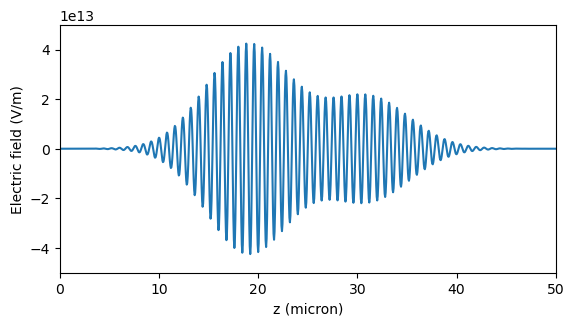

In [75]:
ex = np.fromfile('ex.dat',sep='\n')
z = 0.05 * np.arange(len(ex))
plt.plot(z, ex)
plt.xlim(0, 50)
plt.ylim(-5e13, +5e13)
plt.gca().set_aspect(50/2e14)
plt.xlabel('z (micron)')
plt.ylabel('Electric field (V/m)')
plt.show()

Once the simulation has run, the `final-state/laser` group in the HDF5 output file will contain information about the imported laser pulse.

In [26]:
file = h5py.File('particles.h5')
list(file['final-state/laser'].keys())

['a_rms',
 'absorption',
 'dphi',
 'electric_field',
 'energy_flux',
 'ex',
 'imported_from_file',
 'local_wavelength',
 'phase_step']

Let's import the electric field as a function of phase. Observe that the order has been reversed, because phase is defined as $\phi = \omega_0 (t - z/c)$.

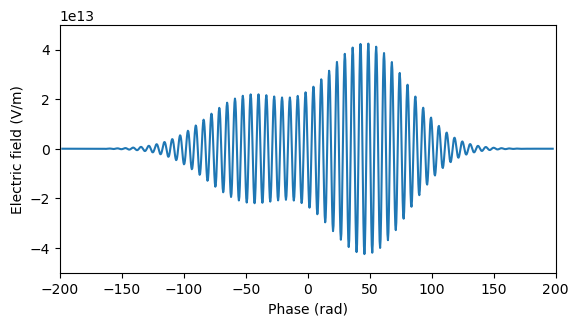

In [77]:
iex = file['final-state/laser/electric_field'][()]
dphi = file['final-state/laser/phase_step'][()]
phase = dphi * (np.arange(len(iex)) - len(iex)/2)
plt.plot(phase, iex)
plt.xlim(-200, 200)
plt.ylim(-5e13, +5e13)
plt.gca().set_aspect(400/2e14)
plt.xlabel('Phase (rad)')
plt.ylabel('Electric field (V/m)')
plt.show()

Using the LMA requires the amplitude (of the vector potential) and wavelength as a function of phase. Ptarmigan will preprocess the electric field to extract the necessary values.

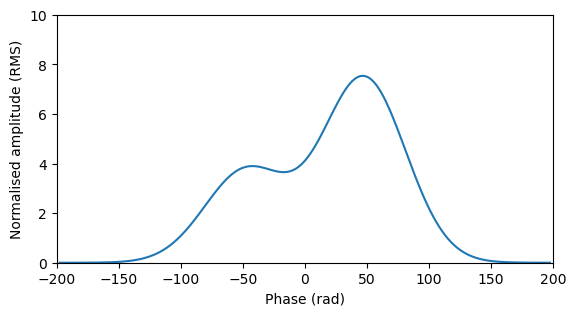

In [78]:
arms = file['final-state/laser/a_rms'][()]
plt.plot(phase, arms)
plt.xlim(-200, 200)
plt.ylim(0, 10)
plt.gca().set_aspect(400/20)
plt.xlabel('Phase (rad)')
plt.ylabel('Normalised amplitude (RMS)')
plt.show()

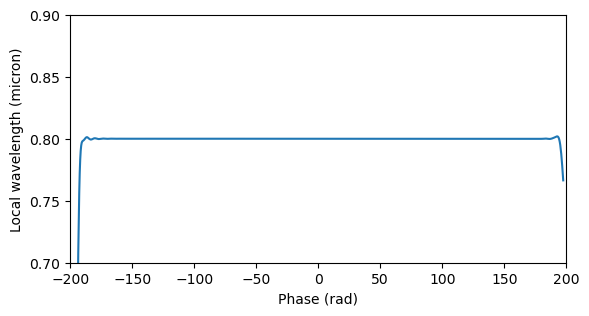

In [81]:
wavelength = file['final-state/laser/local_wavelength'][()]
plt.plot(phase, 1e6 * wavelength)
plt.xlim(-200, 200)
plt.ylim(0.7, 0.9)
plt.gca().set_aspect(400/0.4)
plt.xlabel('Phase (rad)')
plt.ylabel('Local wavelength (micron)')
plt.show()

Deviations from the true value of the local wavelength will be visible near the edges of the pulse, where the amplitude has fallen to very small values.